## LAB-12 DBSCAN Density-based


========== FIRST FIVE RECORDS ==========

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_d

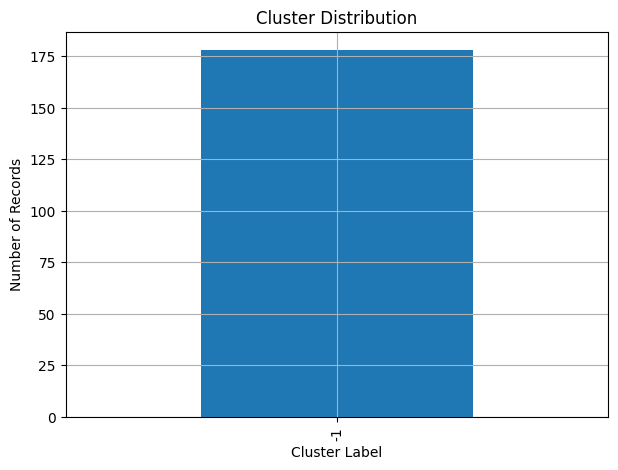

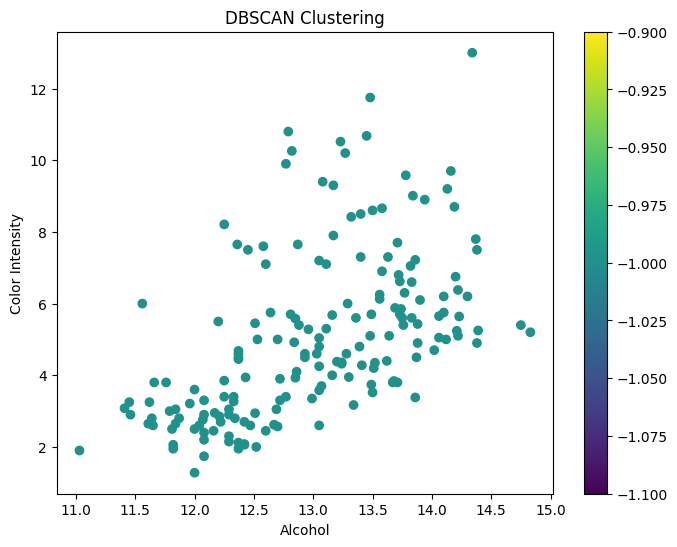

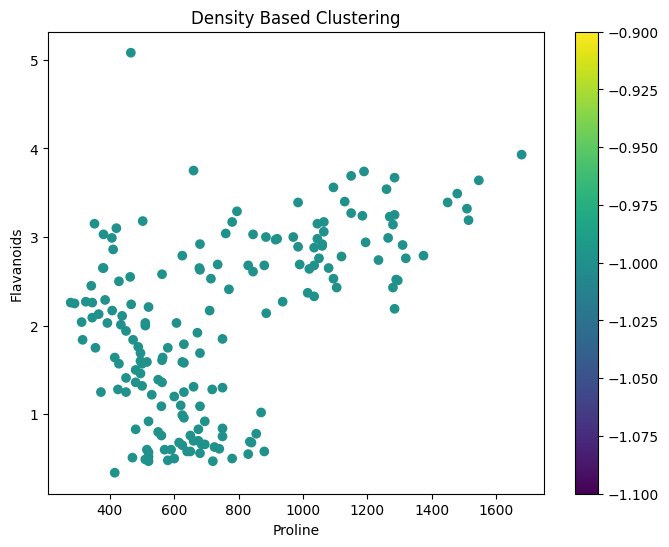


========== DBSCAN SUMMARY ==========
Total Records      : 178
Clusters Found     : 0
Core Points        : 0
Noise Points       : 178
Noise Percentage   : 100.0 %


In [4]:
# ==========================================================
# Experiment 13 : DBSCAN Clustering
# Dataset : Wine Dataset
# MCA AI & DS - Complete 10/10 Version
# ==========================================================

# Step 1 : Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ==========================================================
# Step 2 : Load Dataset
# ==========================================================

wine = load_wine()

X = wine.data

# ==========================================================
# Step 3 : Create DataFrame
# ==========================================================

df = pd.DataFrame(
    X,
    columns=wine.feature_names
)

print("\n========== FIRST FIVE RECORDS ==========\n")

print(df.head())

# ==========================================================
# Step 4 : Dataset Information
# ==========================================================

print("\n========== DATASET INFORMATION ==========\n")

print(df.info())

print("\n========== STATISTICAL SUMMARY ==========\n")

print(df.describe())

# ==========================================================
# Step 5 : Check Missing Values
# ==========================================================

print("\n========== MISSING VALUES ==========\n")

print(df.isnull().sum())

# ==========================================================
# Step 6 : Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling Completed Successfully")

# ==========================================================
# Step 7 : Build DBSCAN Model
# ==========================================================

model = DBSCAN(
    eps=1.5,
    min_samples=5
)

# ==========================================================
# Step 8 : Train Model
# ==========================================================

clusters = model.fit_predict(
    X_scaled
)

# ==========================================================
# Step 9 : Add Cluster Labels
# ==========================================================

df["Cluster"] = clusters

print("\n========== CLUSTER LABELS ADDED ==========\n")

print(df.head())

# ==========================================================
# Step 10 : Number of Clusters
# ==========================================================

n_clusters = len(
    set(clusters)
) - (1 if -1 in clusters else 0)

print(
    "\nNumber of Clusters Found =",
    n_clusters
)

# ==========================================================
# Step 11 : Number of Noise Points
# ==========================================================

noise_points = list(clusters).count(-1)

print(
    "\nNumber of Noise Points =",
    noise_points
)

# ==========================================================
# Step 12 : Cluster Counts
# ==========================================================

print("\n========== CLUSTER COUNTS ==========\n")

print(
    df["Cluster"].value_counts()
)

# ==========================================================
# Step 13 : DBSCAN Parameters
# ==========================================================

print("\n========== DBSCAN PARAMETERS ==========\n")

print(
    "Epsilon (eps) =",
    model.eps
)

print(
    "Minimum Samples =",
    model.min_samples
)

# ==========================================================
# Step 14 : Core Points
# ==========================================================

core_points = len(
    model.core_sample_indices_
)

print(
    "\nNumber of Core Points =",
    core_points
)

# ==========================================================
# Step 15 : Noise Percentage
# ==========================================================

noise_percentage = (
    noise_points / len(df)
) * 100

print(
    "\nNoise Percentage =",
    round(noise_percentage, 2),
    "%"
)

# ==========================================================
# Step 16 : Silhouette Score
# ==========================================================

if n_clusters > 1 and noise_points < len(df):

    score = silhouette_score(
        X_scaled,
        clusters
    )

    print(
        "\nSilhouette Score =",
        round(score, 4)
    )

else:

    score = None

    print(
        "\nSilhouette Score Cannot Be Calculated"
    )

# ==========================================================
# Step 17 : Cluster Distribution Graph
# ==========================================================

plt.figure(figsize=(7,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Cluster Distribution"
)

plt.xlabel(
    "Cluster Label"
)

plt.ylabel(
    "Number of Records"
)

plt.grid(True)

plt.show()

# ==========================================================
# Step 18 : Cluster Visualization 1
# ==========================================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["alcohol"],
    df["color_intensity"],
    c=df["Cluster"]
)

plt.colorbar(scatter)

plt.xlabel(
    "Alcohol"
)

plt.ylabel(
    "Color Intensity"
)

plt.title(
    "DBSCAN Clustering"
)

plt.show()

# ==========================================================
# Step 19 : Cluster Visualization 2
# ==========================================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["proline"],
    df["flavanoids"],
    c=df["Cluster"]
)

plt.colorbar(scatter)

plt.xlabel(
    "Proline"
)

plt.ylabel(
    "Flavanoids"
)

plt.title(
    "Density Based Clustering"
)

plt.show()

# ==========================================================
# Step 20 : DBSCAN Summary
# ==========================================================

print(
    "\n========== DBSCAN SUMMARY =========="
)

print(
    "Total Records      :",
    len(df)
)

print(
    "Clusters Found     :",
    n_clusters
)

print(
    "Core Points        :",
    core_points
)

print(
    "Noise Points       :",
    noise_points
)

print(
    "Noise Percentage   :",
    round(noise_percentage, 2),
    "%"
)

if score is not None:

    print(
        "Silhouette Score   :",
        round(score, 4)
    )
